In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad
import matplotlib.colors as mcolors

In [5]:
sc.settings.n_jobs = 8

In [3]:
def z_score_normalization(data):
    return (data - np.mean(data, axis=0)) / np.std(data, axis=0)

def reorder_columns(df, col_changed, col_position) -> pd.DataFrame:
    """
    Reordering colums. The second input can either be an integer for index or it can be a reference column name. If reference column name is chosen, the column will be placed after the reference column.
    """
    if not isinstance(df, pd.DataFrame):
        raise ValueError("The first argument must be a pandas DataFrame")
    if not isinstance(col_changed, str):
        raise ValueError("The second argument must be a string representing a column name")
    if not isinstance(col_position, (str, int)):
        raise ValueError("The third argument must be either a string representing a column name or an integer representing a column index")
    if isinstance(col_position, int):
        cols = df.columns.tolist()
        if col_changed in cols and col_position <= len(cols) + 1:
            cols.remove(col_changed)
        
            index = col_position
            cols.insert(index, col_changed)
            
            df = df[cols]
    else:
        cols = df.columns.tolist()
        if col_changed in cols and col_position in cols:
            cols.remove(col_changed)
            index = cols.index(col_position)
            cols.insert(index+1, col_changed)
            
            df = df[cols]
    return df

In [2]:
df = pd.read_csv('/Volumes/Lukas_SSD/phenotyping_benchmark/datasets2/IMMUcan/quantification/IMMUcan_combined.csv', index_col=0)

In [ ]:
df.columns

In [ ]:
df.cell_labels.value_counts()

In [ ]:
df.columns

In [3]:
df.drop(columns=['acquisition_id', 'Study', 'SlideId', 'Box.Description', 'Position', 'Indication', 'ROI', 'ROIonSlide', 'includeImage',
                 'flag_no_cells', 'flag_no_ROI', 'flag_total_area', 'flag_percent_covered', 'small_cell', 'SubBatchId', 'SampleId',
                 'flag_tumor', 'PD1_pos', 'Ki67_pos', 'cleavedPARP_pos', 'GrzB_pos', 'tumor_patches', 'distToCells', 'CD20_patches', 'Batch'], inplace=True) 
df.rename(columns={'celltypes': 'cell_type', 'Pos_X': 'x', 'Pos_Y': 'y'}, inplace=True)

In [6]:
df = reorder_columns(df, 'cell_type', 'cell_labels')

In [ ]:
df['BatchId'].nunique()

In [ ]:
df.to_csv('/Volumes/Lukas_SSD/phenotyping_benchmark/datasets2/IMMUcan/quantification/processed/IMMUcan_quantification.csv', index=False)

In [ ]:
df[['image']].nunique()

In [44]:
df

,MPO,HistoneH3,SMA,CD16,CD38,HLADR,CD27,CD15,CD45RA,CD163,...,minor_axis_length,eccentricity,width_px,height_px,cell_labels,level_1_cell_type,level_2_cell_type,true_phenotype,leiden_res0_8,predicted_phenotype
0,0.000000,1.819988,0.502650,1.265410,0.515007,3.331261,0.403800,0.455421,0.528734,2.948392,...,2.780135,0.889904,600,600,M2_Macrophage,Immune,Myeloid_immune,M2_Macrophage,43,Cancer
1,0.196983,2.541684,1.247892,0.161012,1.071582,0.414533,0.735485,0.080994,0.859621,0.289262,...,2.000000,0.935414,600,600,unlabelled,Immune,Lymphoid_immune,Plasma_cell,43,Cancer
2,0.135920,2.393087,1.136961,0.505529,0.605836,0.710857,0.419814,0.100110,0.743002,0.329851,...,3.368407,0.987675,600,600,Stroma,Stromal,Stroma,Stroma,43,Cancer
3,0.210604,2.301097,0.858570,0.422594,0.731755,1.433206,0.373062,0.086509,0.804451,0.340700,...,3.183960,0.944972,600,600,unlabelled,Cancer,Cancer,Cancer,43,Cancer
4,0.165905,2.244917,1.396334,1.744382,0.458541,4.006500,0.003607,0.562882,1.236516,1.747839,...,2.862220,0.841267,600,600,Dendritic_cell,Immune,Myeloid_immune,Dendritic_cell,43,Cancer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457112,0.342312,5.248389,3.919117,2.144037,1.008428,1.917531,1.592820,0.868188,1.364461,0.494844,...,5.435488,0.831990,600,600,unlabelled,Cancer,Cancer,Cancer,8,Stroma
457113,0.110884,3.520289,0.310834,2.590231,2.336469,3.652604,1.443007,0.248852,0.455855,1.025672,...,3.134663,0.956397,600,600,CD8+_T_cell,Immune,Lymphoid_immune,CD8+_T_cell,58,Cancer
457114,0.150941,4.214958,2.651646,0.807826,0.403674,1.226701,0.400776,0.265660,0.513530,0.168271,...,3.228974,0.967988,600,600,Stroma,Stromal,Stroma,Stroma,0,Stroma
457115,0.203716,6.014126,2.757555,2.679402,1.482629,2.401113,1.907091,1.873059,1.597177,0.806173,...,4.323082,0.925851,600,600,unlabelled,Cancer,Cancer,Cancer,33,Cancer


In [34]:
df = pd.read_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/phenotype_benchmark/datasets/test/predictions_1.csv')

In [35]:
X_columns = df.columns[:df.columns.get_loc('image')]
obs_columns =df.columns[df.columns.get_loc('image'):]
adata = ad.AnnData(
    X=df[X_columns],
    obs=df[obs_columns],
    var=pd.DataFrame(index=X_columns)
)

/Users/lukashat/miniforge3/envs/scimap/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [36]:
adata.var_names

Index(['MPO', 'HistoneH3', 'SMA', 'CD16', 'CD38', 'HLADR', 'CD27', 'CD15',
       'CD45RA', 'CD163', 'B2M', 'CD20', 'CD68', 'Ido1', 'CD3', 'LAG3',
       'CD11c', 'PD1', 'PDGFRb', 'CD7', 'GrzB', 'PDL1', 'TCF7', 'CD45RO',
       'FOXP3', 'ICOS', 'CD8a', 'CarbonicAnhydrase', 'CD33', 'Ki67', 'VISTA',
       'CD40', 'CD4', 'CD14', 'Ecad', 'CD303', 'CD206', 'cleavedPARP', 'DNA1',
       'DNA2'],
      dtype='object')

In [42]:
adata.obs.dtypes

image                   object
sample_id               object
cell_id                  int64
x                      float64
y                      float64
area                     int64
major_axis_length      float64
minor_axis_length      float64
eccentricity           float64
width_px                 int64
height_px                int64
cell_labels             object
level_1_cell_type       object
level_2_cell_type       object
true_phenotype          object
leiden_res0_8            int64
predicted_phenotype     object
dtype: object

In [47]:
adata.obs['leiden_res0_8'] = adata.obs['leiden_res0_8'].astype('category')

In [43]:
adata.X

array([[0.        , 0.03760353, 0.01038546, ..., 0.00876608, 0.0983717 ,
        0.10953342],
       [0.0039538 , 0.05101611, 0.02504742, ..., 0.00119714, 0.08640341,
        0.09636128],
       [0.00307517, 0.05414309, 0.0257235 , ..., 0.00268376, 0.11378553,
        0.12513239],
       ...,
       [0.00421092, 0.11758776, 0.07397489, ..., 0.0023427 , 0.13453557,
        0.14957817],
       [0.00288632, 0.08521011, 0.03906994, ..., 0.00336088, 0.06488888,
        0.07348122],
       [0.00843037, 0.10005191, 0.0277594 , ..., 0.0039424 , 0.07643859,
        0.08610641]])

In [39]:

adata.raw = adata.copy()
#adata.X = np.arcsinh(adata.X/1)
adata.layers['zscore'] = z_score_normalization(adata.X)
#adata.obs['cell_type'] = adata.obs['cell_type'].astype('category')


In [40]:
sc.pp.normalize_total(adata, target_sum=1)

In [41]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

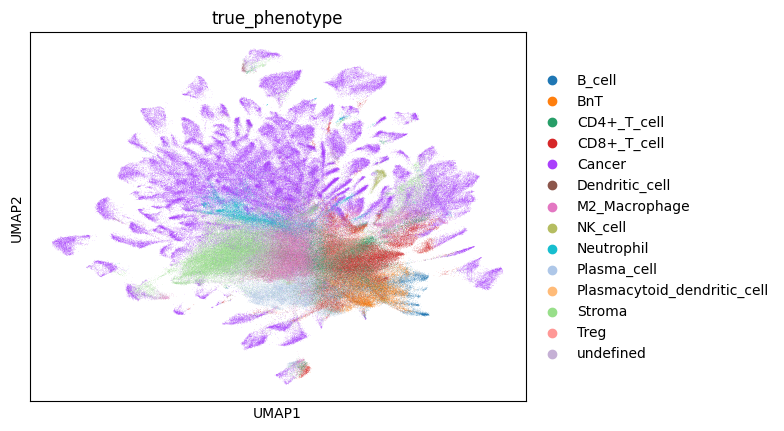

In [45]:
sc.pl.umap(adata, color='true_phenotype')

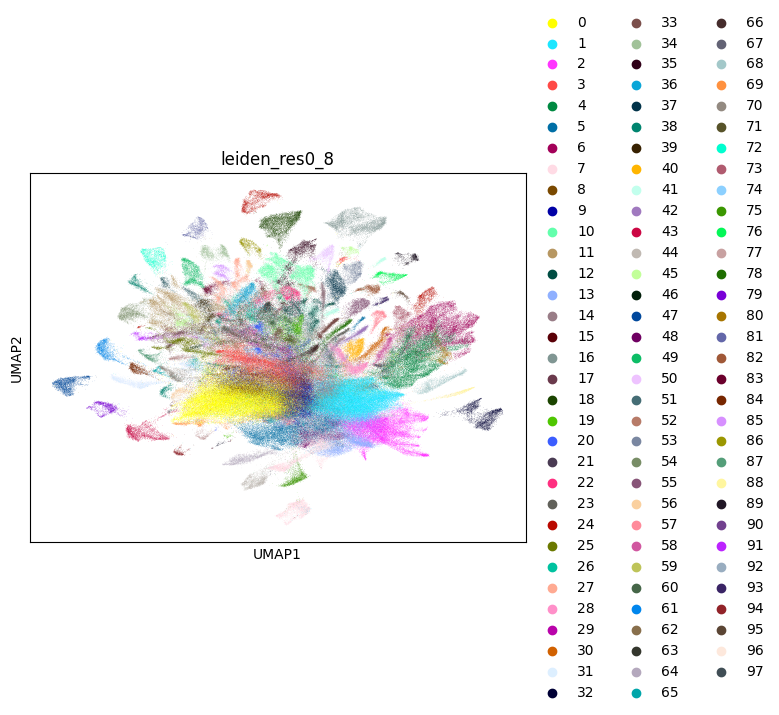

In [48]:
sc.pl.umap(adata, color='leiden_res0_8')

In [49]:
n = adata.obs['sample_id'].nunique()
colors = [plt.cm.hsv(i / n) for i in range(n)]
adata.uns['sample_id_colors'] = [mcolors.to_hex(c) for c in colors]

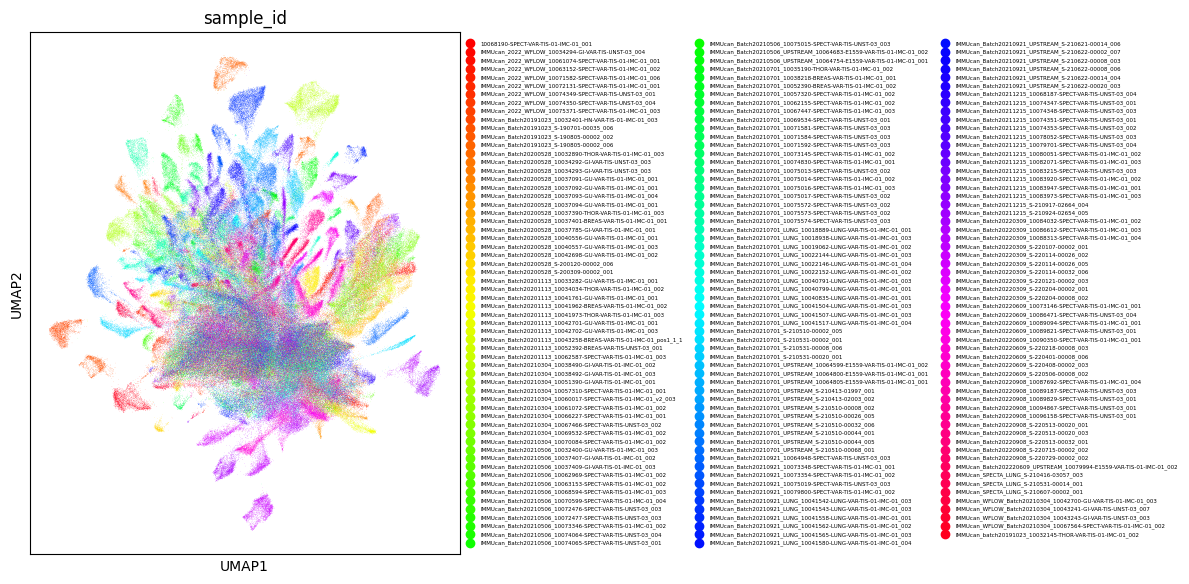

In [52]:
fig, ax = plt.subplots(figsize=(12, 6))
sc.pl.umap(adata, color='sample_id', legend_fontsize=4, ax=ax, show=False)
plt.tight_layout()
plt.show()

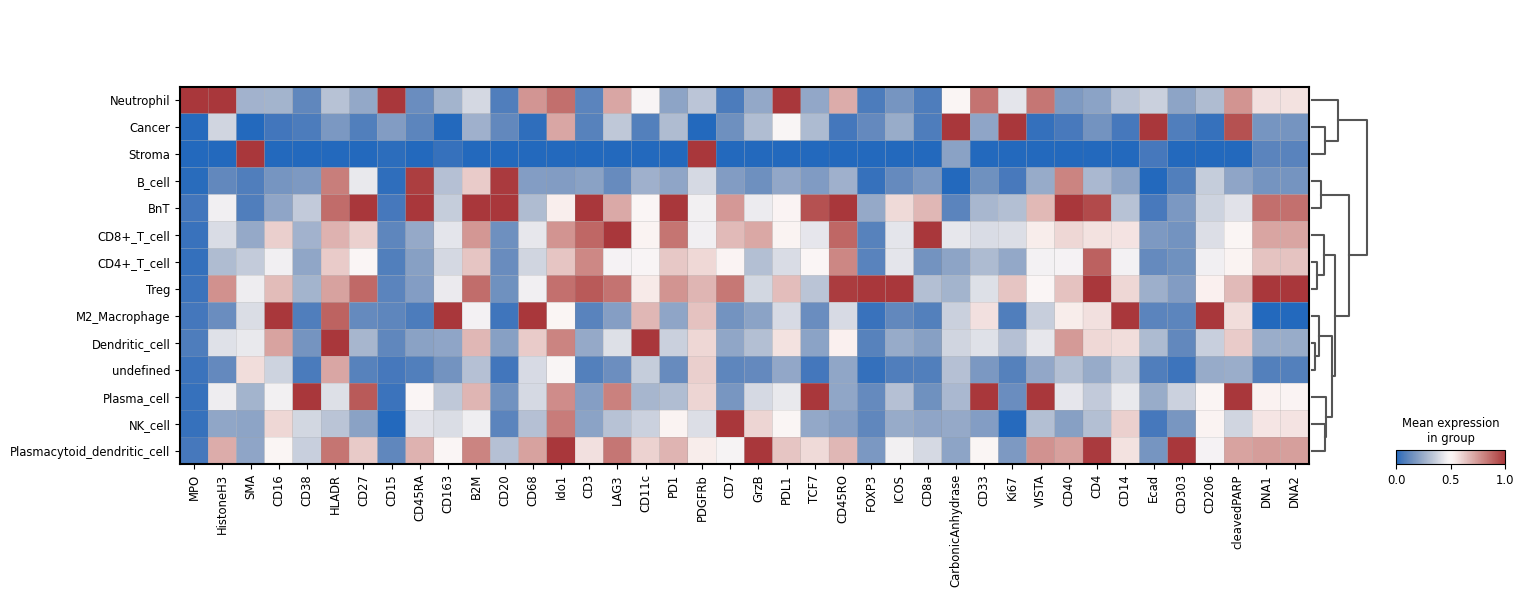

In [5]:
sc.pl.matrixplot(adata, var_names=adata.var_names, groupby='cell_type', cmap='vlag', dendrogram=True, use_raw=False,
                 standard_scale='var'
                 )

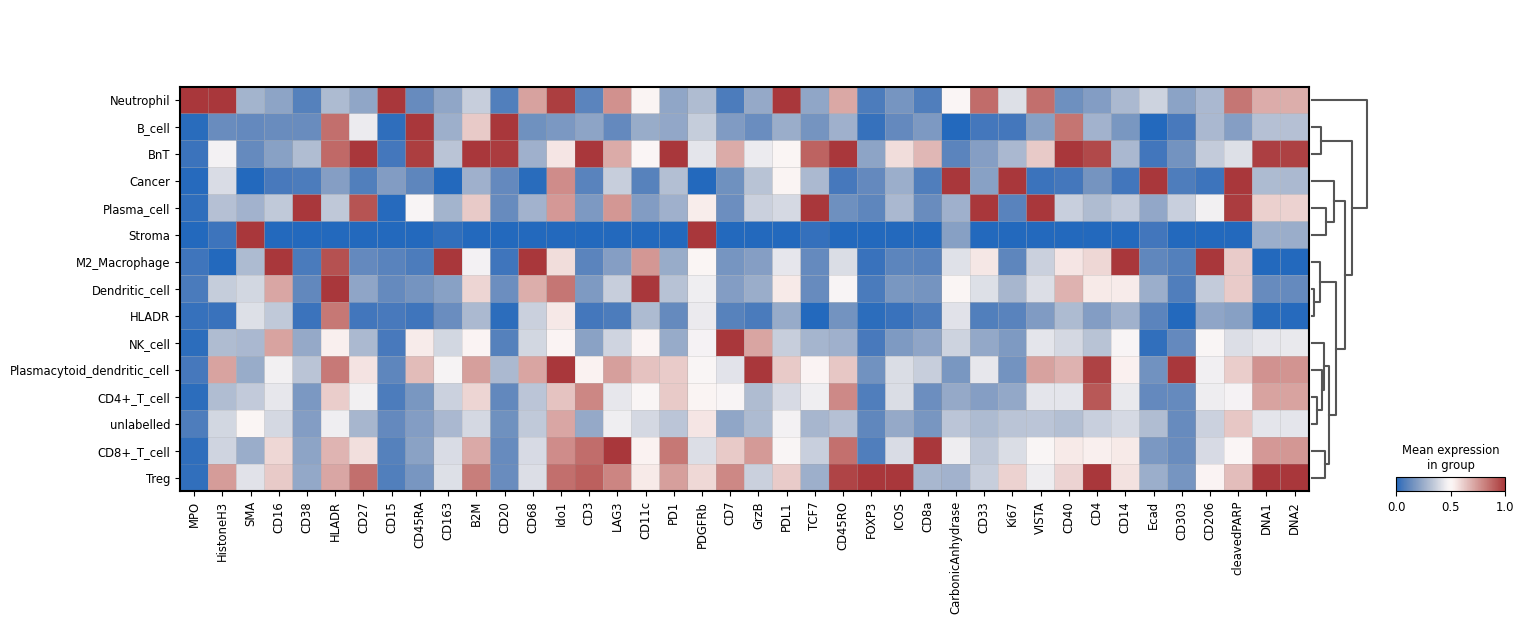

In [6]:
sc.pl.matrixplot(adata, var_names=adata.var_names, groupby='cell_labels', cmap='vlag', dendrogram=True, use_raw=False,
                 standard_scale='var'
                 )

In [ ]:
sc.pp.combat(adata, key='sample_id')

In [ ]:
df = adata.to_df()
for col in adata.obs.columns:
    df[col] = adata.obs[col]

In [ ]:
df

In [ ]:
adata.X

In [ ]:
df.to_csv('/Volumes/Lukas_SSD/phenotyping_benchmark/datasets2/IMMUcan/quantification/processed/IMMUcan_quantification_combat.csv', index=False)

# Harmonize celltype labels

In [3]:
df = pd.read_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/phenotype_benchmark/datasets/IMMUcan_quantification.csv')


In [4]:
df.columns

Index(['MPO', 'HistoneH3', 'SMA', 'CD16', 'CD38', 'HLADR', 'CD27', 'CD15',
       'CD45RA', 'CD163', 'B2M', 'CD20', 'CD68', 'Ido1', 'CD3', 'LAG3',
       'CD11c', 'PD1', 'PDGFRb', 'CD7', 'GrzB', 'PDL1', 'TCF7', 'CD45RO',
       'FOXP3', 'ICOS', 'CD8a', 'CarbonicAnhydrase', 'CD33', 'Ki67', 'VISTA',
       'CD40', 'CD4', 'CD14', 'Ecad', 'CD303', 'CD206', 'cleavedPARP', 'DNA1',
       'DNA2', 'image', 'sample_id', 'cell_id', 'x', 'y', 'area',
       'major_axis_length', 'minor_axis_length', 'eccentricity', 'width_px',
       'height_px', 'cell_labels', 'level_1_cell_type', 'level_2_cell_type',
       'cell_type'],
      dtype='object')

In [ ]:
df['cell_type'] = df['cell_type'].replace({'Tumor' : 'Cancer', 'Mural':'Stroma', 'CD8':'CD8+_T_cell', 'MacCD163':'M2_Macrophage',
                                           'CD4':'CD4+_T_cell', 'plasma':'Plasma_cell','DC':'Dendritic_cell', 'B':'B_cell',
                                           'NK':'NK_cell', 'pDC':'Plasmacytoid_dendritic_cell'})
df['cell_labels'] = df['cell_labels'].replace({'Tumor' : 'Cancer', 'Mural':'Stroma', 'CD8':'CD8+_T_cell', 'MacCD163':'M2_Macrophage',
                                             'CD4':'CD4+_T_cell', 'plasma':'Plasma_cell','DC':'Dendritic_cell', 'B':'B_cell',
                                                'NK':'NK_cell', 'pDC':'Plasmacytoid_dendritic_cell'})
df['cell_type'].value_counts()

In [ ]:
df.to_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/phenotype_benchmark/datasets/IMMUcan_quantification.csv', index=False)

# Implement different levels of granularity

In [1]:
df = pd.read_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/phenotype_benchmark/datasets/IMMUcan_quantification.csv')
df['cell_type'].value_counts()

NameError: name 'pd' is not defined

In [ ]:
df.columns

In [ ]:
df['level_2_cell_type'] = df['cell_type']
df['level_2_cell_type'] = df['level_2_cell_type'].replace({'CD8+_T_cell':'Lymphoid_immune', 'M2_Macrophage':'Myeloid_immune', 'CD4+_T_cell':'Lymphoid_immune', 'Plasma_cell':'Lymphoid_immune',
                                                           'Neutrophil':'Myeloid_immune', 'BnT':'Lymphoid_immune', 'Treg':'Lymphoid_immune', 'Dendritic_cell':'Myeloid_immune', 'B_cell':'Lymphoid_immune',
                                                           'NK_cell':'Lymphoid_immune', 'Plasmacytoid_dendritic_cell':'Myeloid_immune'})
df['level_2_cell_type'].value_counts()

In [ ]:
df['level_1_cell_type'] = df['level_2_cell_type']
df['level_1_cell_type'] = df['level_1_cell_type'].replace({'Lymphoid_immune':'Immune', 'Myeloid_immune':'Immune', 'Stroma':'Stromal'})
df['level_1_cell_type'].value_counts()

In [ ]:
df = reorder_columns(df, 'cell_type', 'level_1_cell_type')
df = reorder_columns(df, 'level_2_cell_type', 'level_1_cell_type')
df 

In [ ]:
df.to_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/phenotype_benchmark/datasets/IMMUcan_quantification.csv', index=False)

# Encode uninfomrative variables with different dtypes

In [3]:
df = pd.read_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/phenotype_benchmark/datasets/IMMUcan_quantification.csv')
df.columns

Index(['MPO', 'HistoneH3', 'SMA', 'CD16', 'CD38', 'HLADR', 'CD27', 'CD15',
       'CD45RA', 'CD163', 'B2M', 'CD20', 'CD68', 'Ido1', 'CD3', 'LAG3',
       'CD11c', 'PD1', 'PDGFRb', 'CD7', 'GrzB', 'PDL1', 'TCF7', 'CD45RO',
       'FOXP3', 'ICOS', 'CD8a', 'CarbonicAnhydrase', 'CD33', 'Ki67', 'VISTA',
       'CD40', 'CD4', 'CD14', 'Ecad', 'CD303', 'CD206', 'cleavedPARP', 'DNA1',
       'DNA2', 'image', 'sample_id', 'cell_id', 'x', 'y', 'area',
       'major_axis_length', 'minor_axis_length', 'eccentricity', 'width_px',
       'height_px', 'cell_labels', 'level_1_cell_type', 'level_2_cell_type',
       'cell_type'],
      dtype='object')

In [12]:
df['cell_type'].nunique()

15

In [5]:
df = df.rename(columns={'ObjectNumber': 'cell_id'})

In [7]:
df.to_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/phenotype_benchmark/datasets/IMMUcan_quantification.csv', index=False)

# Bin celltypes

In [4]:
df = pd.read_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/phenotype_benchmark/datasets/IMMUcan_quantification.csv')
df['cell_type'].value_counts()

cell_type
Cancer                         210853
Stroma                          50127
CD8+_T_cell                     35867
M2_Macrophage                   33882
CD4+_T_cell                     25832
undefined                       18867
Plasma_cell                     17972
Neutrophil                      14723
BnT                             13497
Treg                            10809
Dendritic_cell                  10098
B_cell                           8263
NK_cell                          3412
Plasmacytoid_dendritic_cell      2915
Name: count, dtype: int64

In [9]:
#df['cell_type'] = df['cell_type'].replace({'HLADR':'undefined'})
df['level_1_cell_type'] = df['level_1_cell_type'].replace({'HLADR':'undefined'})
df['level_2_cell_type'] = df['level_2_cell_type'].replace({'HLADR':'undefined'})
df['cell_type'].value_counts()

cell_type
Cancer                         210853
Stroma                          50127
CD8+_T_cell                     35867
M2_Macrophage                   33882
CD4+_T_cell                     25832
undefined                       18867
Plasma_cell                     17972
Neutrophil                      14723
BnT                             13497
Treg                            10809
Dendritic_cell                  10098
B_cell                           8263
NK_cell                          3412
Plasmacytoid_dendritic_cell      2915
Name: count, dtype: int64

In [10]:
df.to_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/phenotype_benchmark/datasets/IMMUcan_quantification.csv', index=False)